In [3]:
# %pip install -e .
%pip install -r ./requirements.txt
%load_ext autoreload
%autoreload 2

ERROR: Could not open requirements file: [Errno 2] Aucun fichier ou dossier de ce nom: './requirements.txt'
Note: you may need to restart the kernel to use updated packages.
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Quick test of the direct-search

<Figure size 1000x600 with 0 Axes>

Running with psstype=1, projection=0, rotation=0, budget=100, simplextype=0

----starting direct-search - budget: 4600 - search dim: 45----
----entering main loop----
it:36, total evals: 1383/4600, loss_per: 1.079e+01, alpha_ds: 1.000e+00, total polls: 34/90
----direct-search finished----
Convergence criterion: full budget used
[   1    2    4   17   30   31   39   52   55   67   80  106  157  212
  268  328  388  478  492  543  633  643  733  749  839  855  920  941
  966 1017 1043 1133 1140 1230 1264 1349 1383 1417 1507 1538 1628 1662
 1752 1786 1876 1941 2031 2053 2143 2193 2283 2348 2438 2456 2546 2614
 2704 2776 2866 2940 3030 3107 3197 3239 3329 3403 3493 3565 3655 3732
 3822 3853 3943 4024 4114 4116 4206 4296 4297 4387 4394 4484 4494 4553
 4600]
Running with psstype=1, projection=1, rotation=0, budget=100, simplextype=0

----starting direct-search - budget: 4600 - search dim: 108----
----entering main loop----
----direct-search finished----
Convergence criterion: full budget use

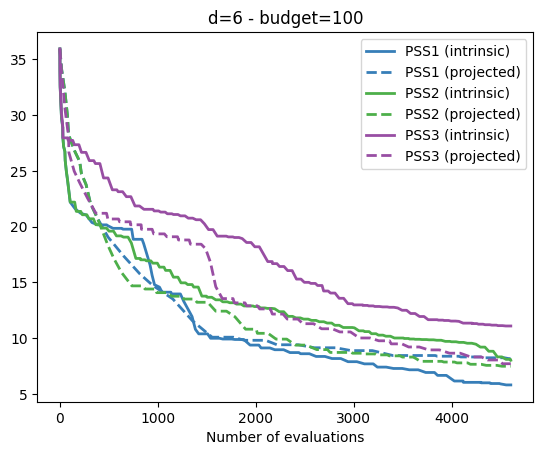

In [17]:
from unittest import result

from ProblemSynchRotations import ProblemSynchRotations
from directsearch import directsearch
import itertools
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl


budget = 100
vd = [6]
n = 3
vinstance = np.arange(0, 1, 1).tolist()
psstypes = [1,2,3]
projections = [0,1]
rotations = [0]
simplextypes = [0] #euclidean


cmapproj = mpl.colormaps["Set1"].colors[1:4]
cmapnoproj = mpl.colormaps["Set1"].colors[1:4]
cmap = [cmapnoproj, cmapproj]
linestyles = ["-", "--"]
linewidths = [2, 1]
variants = ["intrinsic", "projected"]

for d in vd:
    plt.figure(figsize=(10, 6))
    plt.show()
    for instance in vinstance:
        problem = ProblemSynchRotations(n=n, d=d, p=1, eps=1e-6, seed=0)

        for psstype, projection, rotation, simplextype in itertools.product(psstypes, projections, rotations, simplextypes):
            print(f"Running with psstype={psstype}, projection={projection}, rotation={rotation}, budget={budget}, simplextype={simplextype}")
            result_ds = directsearch(
                problem,
                simplexbudget=budget,
                projection=projection,
                psstype=psstype,
                rotation=rotation,
                printing=True)
            res = result_ds
            vf = res["vf"]
            vx = np.cumsum(res["per_iteration_evaluations"])
            cvg = res["stopcriterion"]
            print(f"Convergence criterion: {cvg}")
            print(vx)
            plt.plot(
            vx,vf,
            color=cmap[projection][psstype - 1],
            linestyle=linestyles[projection],
            linewidth=linewidths[rotation],
            label=f"PSS{psstype} ({variants[projection]})",
            )
    plt.title(f"d={d} - budget={budget}")

    plt.xlabel("Number of evaluations")
    plt.legend()


Si $b = 100$ et $d = 10$ et $k=2$, alors nous avons que le nombre total d'évaluation vaut:
$e = 100(2d(d-1)/2+1)=100(91)=9100.

In [ ]:
from operator import ne
from pathlib import Path
import pandas as pd
root = Path("./experiments/2026-04-17_matrixsizek2_v1/results/")
print(root)
results_accs = []
files = list(root.glob("results_*.pkl")) 
print(f"{len(files)} fichiers trouvés dans {root}")

for file in files:
    print(f"Loading {file}")
    loaded = pd.read_pickle(file)
    results_accs.append(loaded)


print(f"{len(results_accs)} fichiers chargés.")



# for results_acc in results_accs:
#     results_acc["rank"] = results_acc["rank"].apply(lambda x: int(x))
#     results_acc = results_acc.sort_values( by=["model","attack", "rank"],
#     key=lambda col: col.astype(str) if col.name == "attack" else col)

#     # results_acc = results_acc.rename(columns={0: "attack", 1: "accuracy"})
# results_accs_concat = pd.concat(results_accs)

experiments/2026-04-17_matrixsizek2_v1/results
1 fichiers trouvés dans experiments/2026-04-17_matrixsizek2_v1/results
Loading experiments/2026-04-17_matrixsizek2_v1/results/results_2026-04-17_00-58-43.pkl
1 fichiers chargés.
